In [2]:
from VSP_Auxiliary import *
from astropy.table import Table
from matplotlib import pyplot as plt

ModuleNotFoundError: No module named 'wget'

In [4]:
def generate_ztf_url(coord, radius=2/3600): 
    # 输入:坐标对象coord，radius单位是度
    # 函数生成ztf光变曲线下载链接并返回url
    end1 = '&FORMAT=CSV'
    part1 = r'https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?'
    search = f'POS=CIRCLE {coord.ra.value} {coord.dec.value} {radius}&BAD_CATFLAGS_MASK=32768&BAD_CATFLAGS_MASK=1'
    url = part1 + search + end1
    url = url.replace(' ', r'%20')
    return url   

# 测试
#c = SkyCoord('02 52 38.57 +20 29 58.1', frame='fk5', unit=(u.hourangle, u.deg))
#generate_ztf_url(c)

'https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?POS=CIRCLE%2043.160708333333325%2020.499472222222224%200.0005555555555555556&BAD_CATFLAGS_MASK=32768&BAD_CATFLAGS_MASK=1&FORMAT=CSV'

In [5]:
def download(coord, save_path):
    # 输入：坐标和保存文件路径
    # 下载ztf光变曲线, 返回文件保存路径，如果没有下载成功则返回False
    if os.path.exists(save_path):
        print(save_path,'already exists.')
        lc = save_path
    else:
        # 生成ztf数据下载链接, 搜索半径2角秒
        url = generate_ztf_url(coord, 2/3600)
        if download_url(url, save_path):
            lc = save_path
        else:
            lc = False
    return lc

# 测试
#c = SkyCoord('02 52 38.57 +20 29 58.1', frame='fk5', unit=(u.hourangle, u.deg))
#download(c,'./Temp/J025238+202958_ztflc.csv')

'./Temp/J025238+202958_ztflc.csv'

In [2]:
def read_lc(path):
    # 输入：ztf光变曲线路径
    # 程序读取光变曲线文件，筛选有效数据catflags=0，返回三个波段的光变曲线Table
    
    # 读入fits数据
    ZTF_hjd = csvc(path,2)
    ZTF_mjd = csvc(path,3)
    ZTF_mag = csvc(path,4)
    ZTF_magerr = csvc(path,5)
    ZTF_flags = csvc(path, 6)
    ZTF_filter = csvc(path,7)


    ZTF_hjd = np.array(ZTF_hjd, dtype=np.float64)
    ZTF_mjd = np.array(ZTF_mjd, dtype=np.float64)
    ZTF_mag = np.array(ZTF_mag, dtype=np.float64)
    ZTF_magerr = np.array(ZTF_magerr, dtype=np.float64)
    ZTF_flags = np.array(ZTF_flags, dtype=np.uint16)

    # 分别保存三个波段
    zg_mag = []
    zg_hjd = []
    zg_err = []

    zr_mag = []
    zr_hjd = []
    zr_err = []

    zi_mag = []
    zi_hjd = []
    zi_err = []
    for i in range(len(ZTF_filter)):
        if ZTF_filter[i] == 'zg' and ZTF_flags[i] == 0:
            zg_mag.append(ZTF_mag[i])
            zg_hjd.append(ZTF_hjd[i])
            zg_err.append(ZTF_magerr[i])
        elif ZTF_filter[i] == 'zr' and ZTF_flags[i] == 0:
            zr_mag.append(ZTF_mag[i])
            zr_hjd.append(ZTF_hjd[i])
            zr_err.append(ZTF_magerr[i])
        elif ZTF_filter[i] == 'zi' and ZTF_flags[i] == 0:
            zi_mag.append(ZTF_mag[i])
            zi_hjd.append(ZTF_hjd[i])
            zi_err.append(ZTF_magerr[i])

    zg_mag=np.array(zg_mag)
    zg_hjd=np.array(zg_hjd)
    zg_err=np.array(zg_err)

    zr_mag=np.array(zr_mag)
    zr_hjd=np.array(zr_hjd)
    zr_err=np.array(zr_err)

    zi_mag=np.array(zi_mag)
    zi_hjd=np.array(zi_hjd)
    zi_err=np.array(zi_err)
    print(path,'have been read.')
    print('data number: zg',len(zg_hjd),'zr',len(zr_hjd),'zi',len(zi_hjd))

    # 将三个波段的数据按时间排序
    hjd_index = np.argsort(zg_hjd)
    zg_hjd1 = zg_hjd[hjd_index]
    zg_mag1 = zg_mag[hjd_index]
    zg_err1 = zg_err[hjd_index]

    hjd_index = np.argsort(zr_hjd)
    zr_hjd1 = zr_hjd[hjd_index]
    zr_mag1 = zr_mag[hjd_index]
    zr_err1 = zr_err[hjd_index]

    hjd_index = np.argsort(zi_hjd)
    zi_hjd1 = zi_hjd[hjd_index]
    zi_mag1 = zi_mag[hjd_index]
    zi_err1 = zi_err[hjd_index]

    tb1,tb2,tb3 = Table(),Table(),Table()
    tb1['hjd_g'],tb1['mag_g'],tb1['magerr_g'] = zg_hjd1,zg_mag1,zg_err1
    tb2['hjd_r'],tb2['mag_r'],tb2['magerr_r'] = zr_hjd1,zr_mag1,zr_err1
    tb3['hjd_i'],tb3['mag_i'],tb3['magerr_i'] = zi_hjd1,zi_mag1,zi_err1
    return (tb1,tb2,tb3)

# 测试
#tbls = read_lc('./Temp/J025238+202958_ztflc.csv')
#tbls

In [3]:
def cal_range(zg_hjd1,zr_hjd1,zi_hjd1,zg_mag1,zr_mag1,zi_mag1):
    if len(zg_hjd1)!=0 and len(zr_hjd1)!=0 and len(zi_hjd1)==0:
        # 计算ztf观测范围
        max_jd = max(max(zg_hjd1),max(zr_hjd1))
        min_jd = min(min(zg_hjd1),min(zr_hjd1))
        # 计算ztf星等范围
        max_mag = max(max(zg_mag1),max(zr_mag1))
        min_mag = min(min(zg_mag1),min(zr_mag1))
    elif len(zg_hjd1)!=0 and len(zr_hjd1)==0 and len(zi_hjd1)!=0:
        # 计算ztf观测范围
        max_jd = max(max(zg_hjd1),max(zi_hjd1))
        min_jd = min(min(zg_hjd1),min(zi_hjd1))
        # 计算ztf星等范围
        max_mag = max(max(zg_mag1),max(zi_mag1))
        min_mag = min(min(zg_mag1),min(zi_mag1))
    elif len(zg_hjd1)==0 and len(zr_hjd1)!=0 and len(zi_hjd1)!=0:
        # 计算ztf观测范围
        max_jd = max(max(zr_hjd1),max(zi_hjd1))
        min_jd = min(min(zr_hjd1),min(zi_hjd1))
        # 计算ztf星等范围
        max_mag = max(max(zr_mag1),max(zi_mag1))
        min_mag = min(min(zr_mag1),min(zi_mag1))
    elif len(zg_hjd1)==0 and len(zr_hjd1)==0 and len(zi_hjd1)!=0:
        # 计算ztf观测范围
        max_jd = max(zi_hjd1)
        min_jd = min(zi_hjd1)
        # 计算ztf星等范围
        max_mag = max(zi_mag1)
        min_mag = min(zi_mag1)
    elif len(zg_hjd1)==0 and len(zr_hjd1)!=0 and len(zi_hjd1)==0:
        # 计算ztf观测范围
        max_jd = max(zr_hjd1)
        min_jd = min(zr_hjd1)
        # 计算ztf星等范围
        max_mag = max(zr_mag1)
        min_mag = min(zr_mag1)
    elif len(zg_hjd1)!=0 and len(zr_hjd1)==0 and len(zi_hjd1)==0:
        # 计算ztf观测范围
        max_jd = max(zg_hjd1)
        min_jd = min(zg_hjd1)
        # 计算ztf星等范围
        max_mag = max(zg_mag1)
        min_mag = min(zg_mag1)
    else:
        # 计算ztf观测范围
        max_jd = max(max(zg_hjd1),max(zr_hjd1),max(zi_hjd1))
        min_jd = min(min(zg_hjd1),min(zr_hjd1),min(zi_hjd1))
        # 计算ztf星等范围
        max_mag = max(max(zg_mag1),max(zr_mag1),max(zi_mag1))
        min_mag = min(min(zg_mag1),min(zr_mag1),min(zi_mag1))
    return min_jd,max_jd,min_mag,max_mag

# 测试

./Temp/J025238+202958_ztflc.csv have been read.
data number: zg 392 zr 616 zi 35
HJD from  2458206.6365598  to  2460353.6712688 	HJD_range: 2147.03
mag from  17.68  to  16.86 			mag_range: 0.8


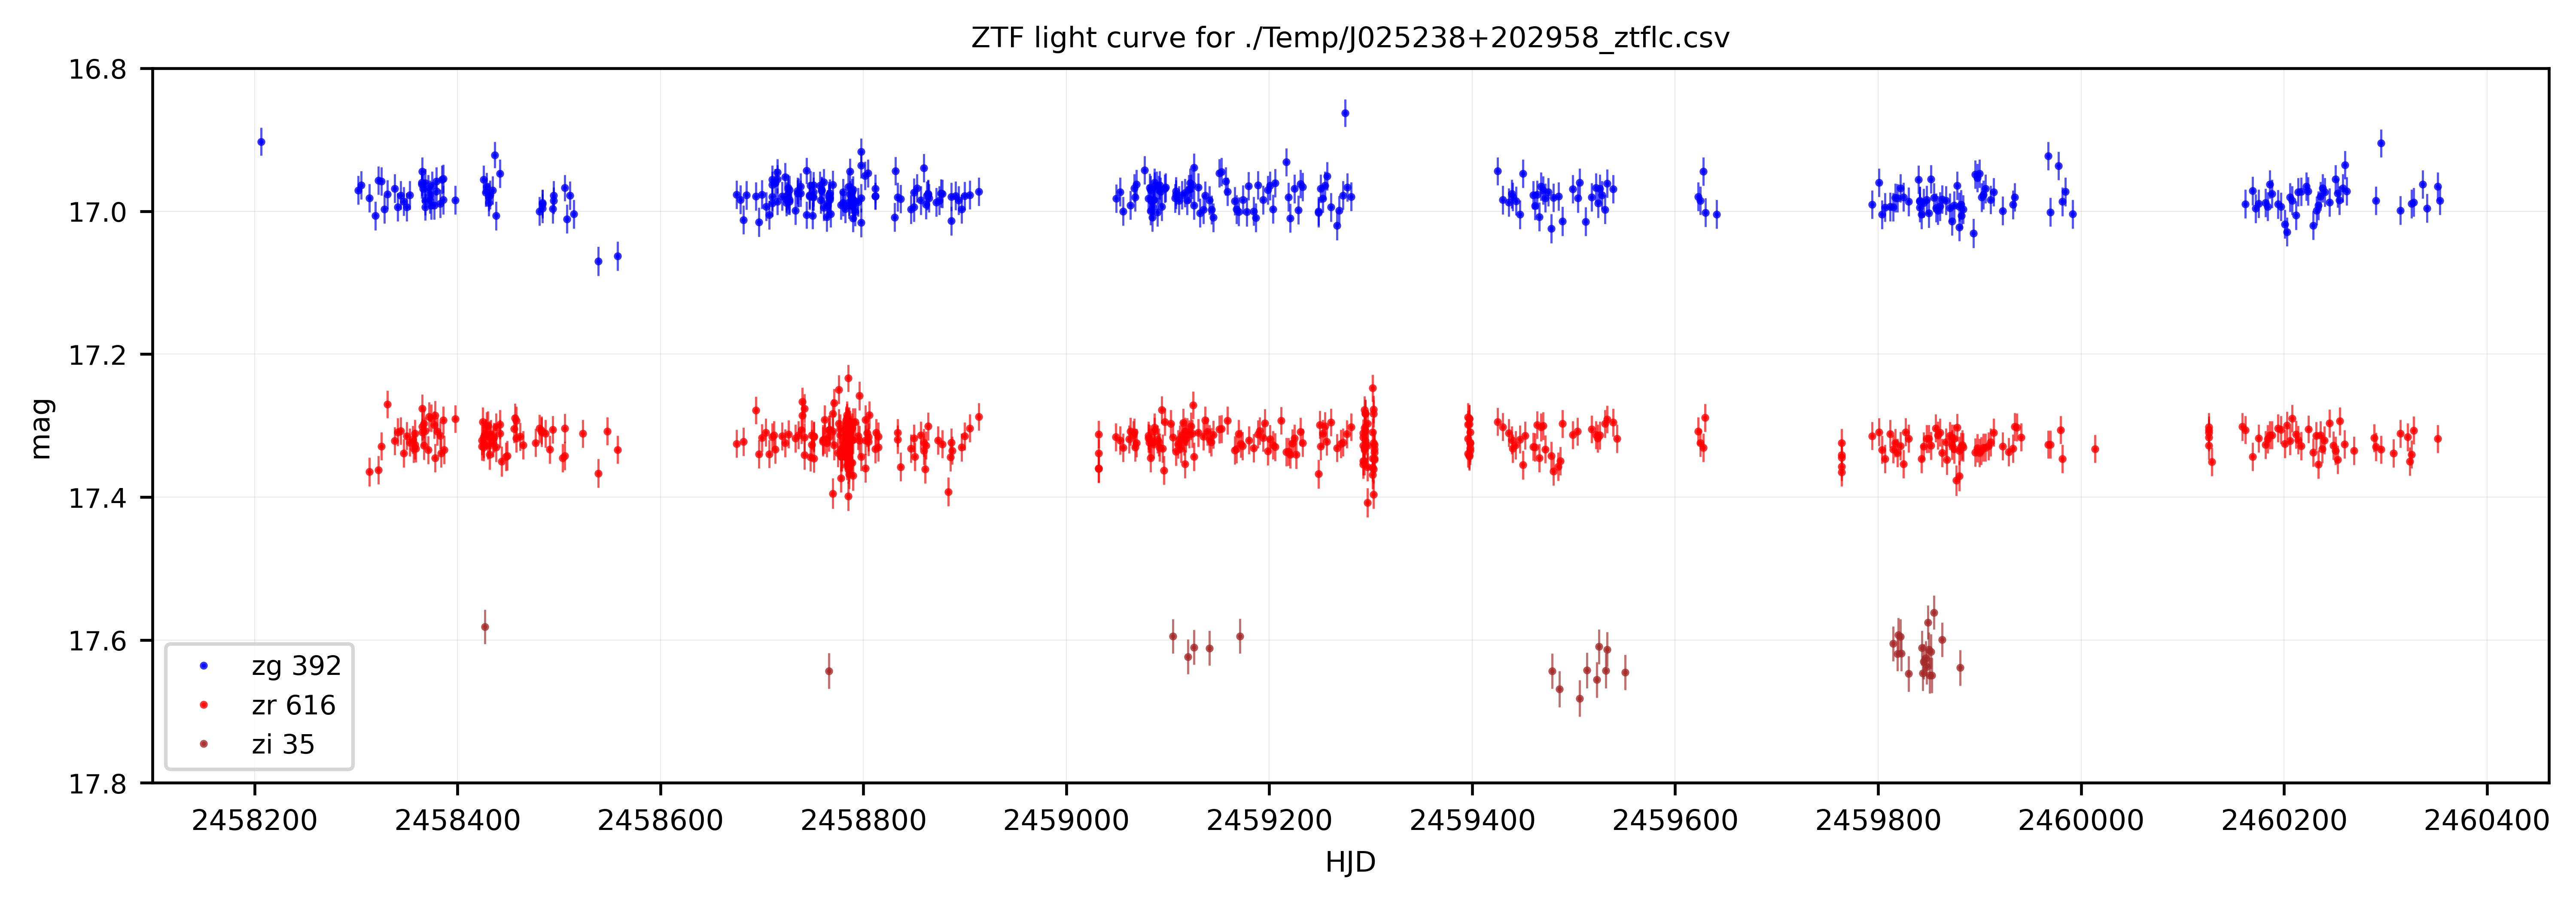

(<Table length=392>
       hjd_g          mag_g      magerr_g  
      float64        float64     float64   
 ------------------ ---------- ------------
   2458206.63655976 16.9026871 0.0195818618
 2458301.9807873145 16.9704552 0.0199481398
  2458304.962425529 16.9633389 0.0199086182
 2458312.9864375703 16.9815445 0.0200102273
  2458318.944889181 17.0063095 0.0201511476
  2458321.945351708 16.9568825 0.0198729821
  2458324.933190008 16.9578552 0.0198783372
                ...        ...          ...
   2460295.69621472  16.904686 0.0195923485
 2460314.7234493997  16.998888 0.0201085862
 2460325.7448820956 16.9895477 0.0200554281
 2460327.6215109276 16.9873924 0.0200432241
  2460336.766306239 16.9622784 0.0199027527
  2460340.791773992 16.9956818 0.0200902838
 2460351.6969524003 16.9651833 0.0199188348
 2460353.6712687905 16.9850254 0.0200298447,
 <Table length=616>
       hjd_r          mag_r      magerr_r  
      float64        float64     float64   
 ------------------ ---------- ----

In [13]:
def plot_ztf(lc_path, save_path=None, ifshow=False):
    # 输入：read_lc()函数读取的数据, 光变曲线图片保存路径
    # 绘制ztf光变曲线,将图片保存到指定路径
    # 返回光变曲线图片保存的路径

    tb1,tb2,tb3 = read_lc(lc_path)
    zg_hjd1,zg_mag1,zg_err1 = tb1['hjd_g'].value,tb1['mag_g'].value,tb1['magerr_g'].value
    zr_hjd1,zr_mag1,zr_err1 = tb2['hjd_r'].value,tb2['mag_r'].value,tb2['magerr_r'].value
    zi_hjd1,zi_mag1,zi_err1 = tb3['hjd_i'].value,tb3['mag_i'].value,tb3['magerr_i'].value
    
    if len(zg_hjd1)!=0 or len(zr_hjd1)!=0 or len(zi_hjd1)!=0: # 不是都为0
        min_jd,max_jd,min_mag,max_mag = cal_range(zg_hjd1,zr_hjd1,zi_hjd1,zg_mag1,zr_mag1,zi_mag1)

        jd_cover = max_jd - min_jd
        x_plot_range = np.arange(min_jd//50*50,max_jd+50,200)
        x_ticks = [str(int(np.round(iii,0))) for iii in x_plot_range]
        print('HJD from ', round(min_jd,7),' to ', round(max_jd,7),'\tHJD_range:',round(jd_cover,2))


        mag_cover = max_mag - min_mag
        y_plot_range = np.arange(min_mag//0.2*0.2,max_mag+0.2,0.2)
        print('mag from ', round(max_mag,2),' to ', round(min_mag,2),'\t\t\tmag_range:',round(mag_cover,1))

        f = plt.figure(figsize=(12,3.6), dpi=600)
        plt.grid(True,zorder=0,linewidth=0.2,alpha=0.2,c='grey')
        ztfzg, = plt.plot(zg_hjd1, zg_mag1, linewidth=0, marker='o', markersize=1.2, 
                          color='b', alpha=0.8,zorder=6)
        plt.errorbar(zg_hjd1, zg_mag1, yerr=zg_err1, linewidth=0, elinewidth=0.6, capsize=0, 
                     color='b', alpha=0.67,zorder=5)
        ztfzr, = plt.plot(zr_hjd1, zr_mag1, linewidth=0, marker='o', markersize=1.2, 
                          color='r', alpha=0.8,zorder=4)
        plt.errorbar(zr_hjd1, zr_mag1, yerr=zr_err1, linewidth=0, elinewidth=0.6, capsize=0, 
                     color='r', alpha=0.67,zorder=3)
        ztfzi, = plt.plot(zi_hjd1, zi_mag1, linewidth=0, marker='o', markersize=1.2, 
                          color='#A52A2A', alpha=0.8,zorder=2)
        plt.errorbar(zi_hjd1, zi_mag1, yerr=zi_err1, linewidth=0, elinewidth=0.6, capsize=0, 
                     color='#A52A2A', alpha=0.67,zorder=1)
        ax = plt.gca()
        ax.invert_yaxis()
        plt.xticks(x_plot_range, x_ticks, fontsize=8)
        plt.yticks(y_plot_range, fontsize=7.5)
        plt.xlabel(r'HJD',fontsize=8)
        plt.ylabel(r'mag',fontsize=8)
        plt.title(f'ZTF light curve for {lc_path}', fontsize=8)
        plt.legend([ztfzg, ztfzr, ztfzi], [f'zg {len(zg_hjd1)}', f'zr {len(zr_hjd1)}',f'zi {len(zi_hjd1)}'], fontsize=7.5)
        if save_path is not None:
            plt.savefig(save_path, bbox_inches = 'tight', dpi=600)
        if ifshow:
            plt.show()
        plt.close(f)
        plt.close()
        plt.close('all')
    else:
        print('Can not plot ZTF data: No valid data points.')
    
    return tb1,tb2,tb3

# 测试
#plot_ztf('./Temp/J025238+202958_ztflc.csv', './Temp/J025238_ztflc3.png', ifshow=True)